In [1]:
# Block 1: imports, parameters, and generic PDP Gaussian calibration

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 1. Basic simulation inputs
# ---------------------------
rng = np.random.default_rng(20260327)

n = 1000                  # sample size
R = 5000                  # Monte Carlo replications
T_Omega = 4.0             # used only when USE_FIXED_TRACE_OMEGA=True
eps = 1.0                 # PDP privacy level epsilon
USE_FIXED_TRACE_OMEGA = False

def clipping_bound_from_trace(trace_Omega):
    return 3.0 * np.sqrt(trace_Omega)


B_reference = clipping_bound_from_trace(T_Omega) if USE_FIXED_TRACE_OMEGA else None

# Lambdas to compare
lambdas = [-0.5, 1.0, 2.0]

# Dense dimension grid: p = 1, 2, ..., 100
p_grid = np.arange(1, 101, dtype=int)

# Covariance-design parameters
rho_ar1 = 0.7
a_het = 2.0   # largest diagonal variance / smallest diagonal variance = 10

# ---------------------------
# 2. Sensitivity of the clipped sample mean
# ---------------------------
def delta_l2_mean(B, n):
    """
    L2 sensitivity of the clipped sample mean:
        Delta_{L2}(Xbar) = 2B / n
    """
    return 2.0 * B / n


# ---------------------------
# 3. Generic PDP Gaussian calibration
# ---------------------------
def kappa_lambda_epsilon(lam, eps):
    """
    Generic PDP calibration constant kappa_{lambda, eps} from Theorem 4.

    For admissible (lambda, eps):
        kappa_{lambda, eps} =
            2 * log(1 + lambda*(lambda+1)*eps) / (lambda*(lambda+1)),
        when lambda*(lambda+1) != 0,

        and kappa = 2*eps for lambda in {0, -1}.

    Admissibility:
    - if lambda*(lambda+1) >= 0, any eps > 0 is allowed;
    - if lambda*(lambda+1) < 0, must have
          0 < eps < -1 / (lambda*(lambda+1)).
    """
    t = lam * (lam + 1.0)

    if np.isclose(t, 0.0):   # lambda = 0 or -1
        if eps <= 0:
            raise ValueError("eps must be positive.")
        return 2.0 * eps

    if eps <= 0:
        raise ValueError("eps must be positive.")

    if t < 0:
        upper = -1.0 / t
        if not (0 < eps < upper):
            raise ValueError(
                f"For lambda={lam}, admissibility requires 0 < eps < {upper:.6g}."
            )

    inside = 1.0 + t * eps
    if inside <= 0:
        raise ValueError(
            f"Invalid log argument: 1 + lambda*(lambda+1)*eps = {inside} <= 0."
        )

    return 2.0 * np.log(inside) / t


def sigma2_privacy(lam, eps, B, n):
    """
    Isotropic Gaussian privacy variance:
        sigma^2_{lambda, eps} = c_{lambda, eps} * Delta^2
                              = Delta^2 / kappa_{lambda, eps}
    """
    Delta = delta_l2_mean(B, n)
    kappa = kappa_lambda_epsilon(lam, eps)
    return Delta**2 / kappa


# ---------------------------
# 4. Compute sigma^2 and crossover p*
# ---------------------------
def pstar_lambda(lam, eps, B, n, T_Omega):
    """
    Crossover dimension p*_lambda defined by

        p*_lambda = T_Omega / (n * sigma^2_{lambda, eps})

    For the clipped mean, Delta = 2B/n, so equivalently

        p*_lambda = T_Omega * n * kappa_{lambda, eps} / (4 B^2).
    """
    kappa = kappa_lambda_epsilon(lam, eps)
    return T_Omega * n * kappa / (4.0 * B**2)


kappa_dict = {lam: kappa_lambda_epsilon(lam, eps) for lam in lambdas}

print(f"USE_FIXED_TRACE_OMEGA = {USE_FIXED_TRACE_OMEGA}")
if USE_FIXED_TRACE_OMEGA:
    sigma2_dict = {lam: sigma2_privacy(lam, eps, B_reference, n) for lam in lambdas}
    pstar_dict = {lam: pstar_lambda(lam, eps, B_reference, n, T_Omega) for lam in lambdas}
    print(f"Reference B = 3 * sqrt(T_Omega) = {B_reference:.6f}")
    print("Delta_L2(Xbar) =", delta_l2_mean(B_reference, n))
    print(f"T_Omega = {T_Omega}, so non-private baseline T_Omega/n = {T_Omega/n:.6f}")
    print("\nReference privacy variances and crossover points:")
    for lam in lambdas:
        print(
            f"lambda = {lam:>5}: "
            f"sigma^2 = {sigma2_dict[lam]:.6e}, "
            f"p* = {pstar_dict[lam]:.3f}"
        )
else:
    print("Using the same non-fixed Omega scaling as simulation_supnorm.ipynb.")
    print("B(p), sigma^2, and the non-private baseline tr(Omega_p)/n are computed inside each (design, p) task.")
    print("\nPrivacy calibration constants:")
    for lam in lambdas:
        print(f"lambda = {lam:>5}: kappa = {kappa_dict[lam]:.6e}")

print("\np_grid =", p_grid)
print(f"\na_het = {a_het} means max diagonal variance / min diagonal variance = {a_het}.")

USE_FIXED_TRACE_OMEGA = False
Using the same non-fixed Omega scaling as simulation_supnorm.ipynb.
B(p), sigma^2, and the non-private baseline tr(Omega_p)/n are computed inside each (design, p) task.

Privacy calibration constants:
lambda =  -0.5: kappa = 2.301457e+00
lambda =   1.0: kappa = 1.098612e+00
lambda =   2.0: kappa = 6.486367e-01

p_grid = [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]

a_het = 2.0 means max diagonal variance / min diagonal variance = 2.0.


In [2]:
# Block 2: construct Omega_p for the two designs, with the same fixed/non-fixed trace option as simulation_supnorm.ipynb

def omega_ar1(p, rho, use_fixed_trace=True, T_Omega=None):
    """
    AR(1)-type covariance matrix with entries rho^{|i-j|}.

    If use_fixed_trace=True, rescale so that trace(Omega_p) = T_Omega.
    Otherwise keep the raw AR(1) covariance scale.

    Parameters
    ----------
    p : int
        Dimension.
    rho : float
        AR(1) correlation parameter. Should satisfy |rho| < 1 for a standard AR(1) correlation form.
    use_fixed_trace : bool
        Whether to normalize to trace T_Omega.
    T_Omega : float or None
        Target trace when use_fixed_trace=True.

    Returns
    -------
    Omega : ndarray of shape (p, p)
        Positive definite covariance matrix.
    """
    idx = np.arange(p)
    Omega = rho ** np.abs(np.subtract.outer(idx, idx))

    if use_fixed_trace:
        if T_Omega is None:
            raise ValueError("T_Omega must be provided when use_fixed_trace=True.")
        Omega = Omega * (T_Omega / np.trace(Omega))

    return Omega


def omega_heterogeneous_diag(p, a, use_fixed_trace=True, T_Omega=None):
    """
    Heterogeneous diagonal covariance matrix.

    Raw diagonal weights are
        w_j = a^{(j-1)/(p-1)},   j = 1,...,p,
    then optionally rescaled so that sum_j w_j = T_Omega.

    Interpretation:
    - smallest diagonal variance = d_min
    - largest diagonal variance = d_max
    - ratio d_max / d_min = a

    Parameters
    ----------
    p : int
        Dimension.
    a : float
        Heterogeneity ratio; must be positive.
        If a = 1, all diagonal entries are equal.
    use_fixed_trace : bool
        Whether to normalize to trace T_Omega.
    T_Omega : float or None
        Target trace when use_fixed_trace=True.

    Returns
    -------
    Omega : ndarray of shape (p, p)
        Diagonal covariance matrix.
    """
    if a <= 0:
        raise ValueError("a must be positive.")

    if p == 1:
        if use_fixed_trace:
            return np.array([[T_Omega]], dtype=float)
        return np.array([[1.0]], dtype=float)

    exponents = np.arange(p) / (p - 1)
    w = a ** exponents
    if use_fixed_trace:
        if T_Omega is None:
            raise ValueError("T_Omega must be provided when use_fixed_trace=True.")
        w = T_Omega * w / np.sum(w)

    d = w
    Omega = np.diag(d)
    return Omega


def omega_by_design(design, p):
    if design == "ar1":
        return omega_ar1(p, rho_ar1, use_fixed_trace=USE_FIXED_TRACE_OMEGA, T_Omega=T_Omega)
    if design == "het":
        return omega_heterogeneous_diag(p, a_het, use_fixed_trace=USE_FIXED_TRACE_OMEGA, T_Omega=T_Omega)
    raise ValueError("design must be 'ar1' or 'het'.")


def clipping_bound_from_p(p, design):
    Omega = omega_by_design(design, p)
    B_p = 3.0 * np.sqrt(np.trace(Omega))
    return B_p, Omega


# --------------------------------------------------
# Quick sanity checks on a few dimensions from p_grid
# --------------------------------------------------
p_check_list = [p_grid[0], p_grid[len(p_grid)//2], p_grid[-1]]

for p in p_check_list:
    Omega_ar1 = omega_by_design("ar1", p)
    Omega_het = omega_by_design("het", p)

    diag_het = np.diag(Omega_het)

    print(f"\n===== p = {p} =====")
    print("AR1 design:")
    print(f"  trace(Omega_ar1) = {np.trace(Omega_ar1):.6f}")
    print(f"  min eigenvalue   = {np.linalg.eigvalsh(Omega_ar1).min():.6e}")
    print(f"  first diagonal   = {Omega_ar1[0,0]:.6e}")
    print(f"  offdiag (1,2)    = {Omega_ar1[0,1]:.6e}" if p > 1 else "  offdiag not applicable")

    print("Heterogeneous diagonal design:")
    print(f"  trace(Omega_het) = {np.trace(Omega_het):.6f}")
    print(f"  smallest diag    = {diag_het.min():.6e}")
    print(f"  largest diag     = {diag_het.max():.6e}")
    print(f"  max/min ratio    = {diag_het.max()/diag_het.min():.6f}")


# --------------------------------------------------
# Optional: inspect one example more closely
# --------------------------------------------------
p_example = p_grid[len(p_grid)//2]

Omega_ar1_example = omega_by_design("ar1", p_example)
Omega_het_example = omega_by_design("het", p_example)

print(f"\nExample p = {p_example}")
print("Top-left 5x5 block of AR1 Omega:")
print(Omega_ar1_example[:5, :5])

print("\nFirst 10 diagonal entries of heterogeneous Omega:")
print(np.diag(Omega_het_example)[:10])


===== p = 1 =====
AR1 design:
  trace(Omega_ar1) = 1.000000
  min eigenvalue   = 1.000000e+00
  first diagonal   = 1.000000e+00
  offdiag not applicable
Heterogeneous diagonal design:
  trace(Omega_het) = 1.000000
  smallest diag    = 1.000000e+00
  largest diag     = 1.000000e+00
  max/min ratio    = 1.000000

===== p = 51 =====
AR1 design:
  trace(Omega_ar1) = 51.000000
  min eigenvalue   = 1.766318e-01
  first diagonal   = 1.000000e+00
  offdiag (1,2)    = 7.000000e-01
Heterogeneous diagonal design:
  trace(Omega_het) = 73.635907
  smallest diag    = 1.000000e+00
  largest diag     = 2.000000e+00
  max/min ratio    = 2.000000

===== p = 100 =====
AR1 design:
  trace(Omega_ar1) = 100.000000
  min eigenvalue   = 1.765126e-01
  first diagonal   = 1.000000e+00
  offdiag (1,2)    = 7.000000e-01
Heterogeneous diagonal design:
  trace(Omega_het) = 144.327393
  smallest diag    = 1.000000e+00
  largest diag     = 2.000000e+00
  max/min ratio    = 2.000000

Example p = 51
Top-left 5x5 block

In [3]:
# Block 3: parallel simulation that can run inside a Windows notebook

from collections import defaultdict
from joblib import Parallel, delayed, parallel_config
import os

N_JOBS = -1                          # all CPU cores
INNER_BATCH = 5                      # small replication batch inside each p-task


def _one_p_task(p, total_reps, seed):
    rng = np.random.default_rng(seed)
    mean0 = np.zeros(p)
    rows = []

    for design in ["ar1", "het"]:
        B_p, Omega = clipping_bound_from_p(p, design)
        sigma2_dict = {lam: sigma2_privacy(lam, eps, B_p, n) for lam in lambdas}

        out = {
            lam: {"count": 0, "sum_sqerr": 0.0, "sum_sqerr2": 0.0}
            for lam in lambdas
        }

        done = 0
        while done < total_reps:
            b = min(INNER_BATCH, total_reps - done)

            X = rng.multivariate_normal(
                mean=mean0,
                cov=Omega,
                size=(b, n),
                method="eigh",
                check_valid="raise"
            )
            Xbar = X.mean(axis=1)

            for lam in lambdas:
                sigma2 = sigma2_dict[lam]
                Z = rng.normal(0.0, np.sqrt(sigma2), size=(b, p))
                sqerr = np.sum((Xbar + Z) ** 2, axis=1)

                out[lam]["count"] += b
                out[lam]["sum_sqerr"] += float(np.sum(sqerr))
                out[lam]["sum_sqerr2"] += float(np.sum(sqerr ** 2))

            done += b

        for lam in lambdas:
            rows.append({
                "design": design,
                "p": p,
                "lambda": lam,
                "count": out[lam]["count"],
                "sum_sqerr": out[lam]["sum_sqerr"],
                "sum_sqerr2": out[lam]["sum_sqerr2"],
            })

    return rows


def run_parallel_simulation():
    tasks = []
    seed_seq = np.random.SeedSequence(20260327)
    child_seeds = seed_seq.spawn(len(p_grid))

    k = 0
    for p in p_grid:
        seed = int(child_seeds[k].generate_state(1)[0])
        k += 1
        tasks.append((int(p), int(R), seed))

    with parallel_config(backend="loky", inner_max_num_threads=1):
        partial = Parallel(n_jobs=N_JOBS)(
            delayed(_one_p_task)(p, total_reps, seed)
            for p, total_reps, seed in tasks
        )

    agg = defaultdict(lambda: {"count": 0, "sum_sqerr": 0.0, "sum_sqerr2": 0.0})
    for res in partial:
        for row in res:
            key = (row["design"], row["p"], row["lambda"])
            agg[key]["count"] += row["count"]
            agg[key]["sum_sqerr"] += row["sum_sqerr"]
            agg[key]["sum_sqerr2"] += row["sum_sqerr2"]

    rows = []

    for design in ["ar1", "het"]:
        for lam in lambdas:
            for p in p_grid:
                g = agg[(design, p, lam)]
                count = g["count"]
                B_p, Omega = clipping_bound_from_p(p, design)
                trace_Omega = float(np.trace(Omega))
                baseline = trace_Omega / n

                mse_emp = g["sum_sqerr"] / count
                var_sqerr = (g["sum_sqerr2"] - count * mse_emp**2) / (count - 1)
                mse_mc_se = np.sqrt(var_sqerr / count)

                sigma2 = sigma2_privacy(lam, eps, B_p, n)
                mse_theory = baseline + p * sigma2
                risk_emp = mse_emp / baseline
                risk_theory = mse_theory / baseline

                rows.append({
                    "design": design,
                    "p": p,
                    "p_over_n": p / n,
                    "lambda": lam,
                    "B": B_p,
                    "trace_Omega": trace_Omega,
                    "sigma2": sigma2,
                    "mse_emp": mse_emp,
                    "mse_mc_se": mse_mc_se,
                    "risk_emp": risk_emp,
                    "mse_theory": mse_theory,
                    "risk_theory": risk_theory,
                    "p_star": pstar_lambda(lam, eps, B_p, n, trace_Omega),
                })

    return pd.DataFrame(rows).sort_values(["design", "lambda", "p"]).reset_index(drop=True)


results_all = run_parallel_simulation()
display(results_all.head(12))

print("logical CPUs:", os.cpu_count() or 1)
print("parallel tasks (one per p):", len(p_grid))
print("inner batch:", INNER_BATCH)

,design,p,p_over_n,lambda,B,trace_Omega,sigma2,mse_emp,mse_mc_se,risk_emp,mse_theory,risk_theory,p_star
0,ar1,1,0.001,-0.5,3.000000,1.0,0.000016,0.001019,0.000020,1.019427,0.001016,1.015642,63.929349
1,ar1,2,0.002,-0.5,4.242641,2.0,0.000031,0.002107,0.000035,1.053730,0.002063,1.031285,63.929349
2,ar1,3,0.003,-0.5,5.196152,3.0,0.000047,0.003021,0.000046,1.006913,0.003141,1.046927,63.929349
3,ar1,4,0.004,-0.5,6.000000,4.0,0.000063,0.004228,0.000058,1.057081,0.004250,1.062569,63.929349
4,ar1,5,0.005,-0.5,6.708204,5.0,0.000078,0.005369,0.000068,1.073744,0.005391,1.078211,63.929349
5,ar1,6,0.006,-0.5,7.348469,6.0,0.000094,0.006485,0.000075,1.080846,0.006563,1.093854,63.929349
6,ar1,7,0.007,-0.5,7.937254,7.0,0.000109,0.007749,0.000082,1.107032,0.007766,1.109496,63.929349
7,ar1,8,0.008,-0.5,8.485281,8.0,0.000125,0.008870,0.000089,1.108799,0.009001,1.125138,63.929349
8,ar1,9,0.009,-0.5,9.000000,9.0,0.000141,0.010177,0.000101,1.130724,0.010267,1.140780,63.929349
9,ar1,10,0.010,-0.5,9.486833,10.0,0.000156,0.011797,0.000113,1.179662,0.011564,1.156423,63.929349


logical CPUs: 36
parallel tasks (one per p): 100
inner batch: 5


In [4]:
# # Block 3: simulate by generating X_1,...,X_n with multivariate_normal, then averaging

# def simulate_one_design_fullsample_mvn(
#     design_name,
#     p_grid,
#     lambdas,
#     R,
#     n,
#     T_Omega,
#     sigma2_dict,
#     eps,
#     B,
#     rho_ar1=None,
#     a_het=None,
#     batch_size=5,
#     rng=None
# ):
#     """
#     Monte Carlo simulation by generating the full sample:
#         X_1, ..., X_n iid N(0, Omega_p)
#     inside each replication, then forming the sample mean.

#     Uses:
#         rng.multivariate_normal(mean, cov, size=(b, n))
#     so the output has shape (b, n, p).
#     """
#     if rng is None:
#         rng = np.random.default_rng(20260327)

#     rows = []

#     for p in p_grid:
#         baseline = T_Omega / n

#         # Build Omega_p once for this p
#         if design_name.lower() == "ar1":
#             Omega_p = omega_ar1(p, T_Omega, rho_ar1)
#         elif design_name.lower() == "het":
#             Omega_p = omega_heterogeneous_diag(p, T_Omega, a_het)
#         else:
#             raise ValueError("design_name must be either 'ar1' or 'het'.")

#         mean_vec = np.zeros(p)

#         sum_sqerr = {lam: 0.0 for lam in lambdas}
#         sum_sqerr2 = {lam: 0.0 for lam in lambdas}
#         total_count = 0

#         for start in range(0, R, batch_size):
#             b = min(batch_size, R - start)

#             # X has shape (b, n, p)
#             X = rng.multivariate_normal(
#                 mean=mean_vec,
#                 cov=Omega_p,
#                 size=(b, n),
#                 check_valid="raise",
#                 method="cholesky"
#             )

#             # One sample mean per replication: shape (b, p)
#             Xbar_batch = X.mean(axis=1)

#             for lam in lambdas:
#                 sigma2 = sigma2_dict[lam]
#                 sigma = np.sqrt(sigma2)

#                 Z = sigma * rng.standard_normal(size=(b, p))
#                 sq_errors = np.sum((Xbar_batch + Z) ** 2, axis=1)

#                 sum_sqerr[lam] += sq_errors.sum()
#                 sum_sqerr2[lam] += np.sum(sq_errors ** 2)

#             total_count += b

#         for lam in lambdas:
#             mse_emp = sum_sqerr[lam] / total_count

#             if total_count > 1:
#                 var_sqerr = (
#                     sum_sqerr2[lam] - total_count * mse_emp**2
#                 ) / (total_count - 1)
#                 mse_mc_se = np.sqrt(var_sqerr / total_count)
#             else:
#                 mse_mc_se = np.nan

#             risk_emp = mse_emp / baseline
#             mse_theory = baseline + p * sigma2_dict[lam]
#             risk_theory = mse_theory / baseline

#             rows.append({
#                 "design": design_name.lower(),
#                 "p": p,
#                 "p_over_n": p / n,
#                 "lambda": lam,
#                 "sigma2": sigma2_dict[lam],
#                 "baseline": baseline,
#                 "mse_emp": mse_emp,
#                 "mse_mc_se": mse_mc_se,
#                 "risk_emp": risk_emp,
#                 "mse_theory": mse_theory,
#                 "risk_theory": risk_theory,
#                 "p_star": pstar_lambda(lam, eps, B, n, T_Omega)
#             })

#         print(f"Finished design={design_name}, p={p}")

#     return pd.DataFrame(rows)


# # Run both designs
# results_ar1 = simulate_one_design_fullsample_mvn(
#     design_name="ar1",
#     p_grid=p_grid,
#     lambdas=lambdas,
#     R=R,
#     n=n,
#     T_Omega=T_Omega,
#     sigma2_dict=sigma2_dict,
#     eps=eps,
#     B=B,
#     rho_ar1=rho_ar1,
#     batch_size=5,
#     rng=rng
# )

# results_het = simulate_one_design_fullsample_mvn(
#     design_name="het",
#     p_grid=p_grid,
#     lambdas=lambdas,
#     R=R,
#     n=n,
#     T_Omega=T_Omega,
#     sigma2_dict=sigma2_dict,
#     eps=eps,
#     B=B,
#     a_het=a_het,
#     batch_size=5,
#     rng=rng
# )

# results_all = pd.concat([results_ar1, results_het], ignore_index=True)
# results_all = results_all.sort_values(["design", "lambda", "p"]).reset_index(drop=True)

# display(results_all.head(12))

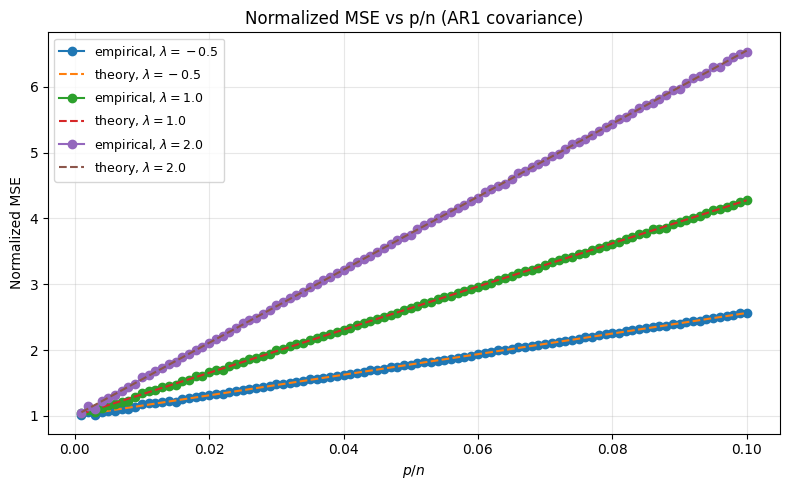

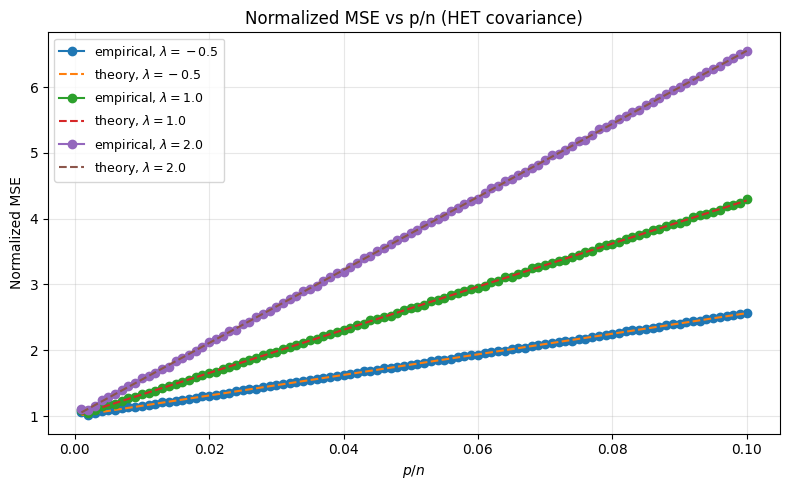

In [5]:
# Block 4: plot normalized MSE vs p/n for each lambda, separately for AR1 and heterogeneous Omega

from pathlib import Path

def plot_normalized_mse(results_df, lambdas, save_dir="figures"):
    save_dir = Path(save_dir) if save_dir is not None else None
    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)

    """
    Plot normalized MSE vs p/n for each lambda.
    One figure for each covariance design.
    """
    for design in ["ar1", "het"]:
        df_design = results_df[results_df["design"] == design].copy()

        plt.figure(figsize=(8, 5))

        for lam in lambdas:
            df_lam = df_design[df_design["lambda"] == lam].sort_values("p")

            x = df_lam["p_over_n"].to_numpy()
            y_emp = df_lam["risk_emp"].to_numpy()
            y_theory = df_lam["risk_theory"].to_numpy()
            x_star = df_lam["p_star"].iloc[0] / n

            # empirical curve
            plt.plot(
                x, y_emp, marker="o",
                label=fr"empirical, $\lambda={lam}$"
            )

            # theoretical curve
            plt.plot(
                x, y_theory, linestyle="--",
                label=fr"theory, $\lambda={lam}$"
            )

            # vertical line at p*/n
            # plt.axvline(
            #     x=x_star,
            #     linestyle=":",
            #     alpha=0.8
            # )

        plt.xlabel(r"$p/n$")
        plt.ylabel("Normalized MSE")
        plt.title(f"Normalized MSE vs p/n ({design.upper()} covariance)")
        plt.legend(fontsize=9)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        if save_dir is not None:
            plt.savefig(
                save_dir / f"normalized_mse_{design}_p_over_n.png",
                dpi=300,
                bbox_inches="tight"
            )

        plt.show()

# Save figures into ./figures while displaying them
save_dir = "figures"

plot_normalized_mse(results_all, lambdas, save_dir=save_dir)